In [22]:
from datasets import load_from_disk
import numpy as np
from scipy.special import log_softmax
import matplotlib.pyplot as plt

In [29]:
ds = load_from_disk("../experiments/glue_sst2_orig/tinyllama/all/train").flatten()
ds

Dataset({
    features: ['idx', 'input.answers', 'input.prompt', 'target', 'output.logits', 'output.prompt_hidden_states'],
    num_rows: 10000
})

In [30]:
logits = ds.with_format("numpy",columns=["output.logits"])["output.logits"]
labels = ds.with_format("numpy",columns=["target"])["target"]

# compute cross-entropy
logprobs = log_softmax(logits, axis=1)
metric = -np.mean(logprobs[np.arange(len(labels)), labels])
priors = np.bincount(labels) / len(labels)
naive_metric = -np.mean(np.log(priors[labels]))
metric / naive_metric


1.209483643984938

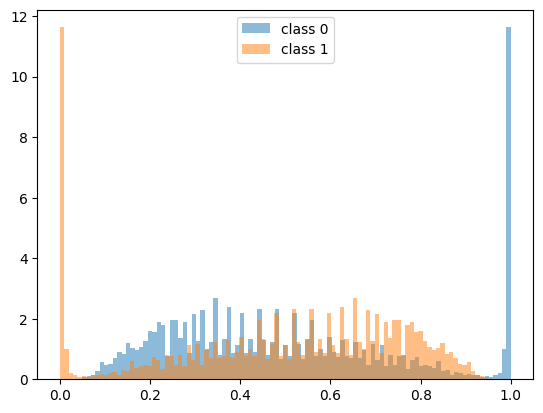

In [38]:
for i in np.unique(labels):
    plt.hist(np.exp(logprobs[:,i]), bins=100, alpha=0.5, label=f"class {i}", density=True)
plt.legend()

In [32]:
priors

array([0.4488, 0.5512])

In [37]:
np.histogram(np.exp(logprobs), bins=100)

(array([1128,   97,   24,   14,   10,   16,   21,   29,   40,   70,   81,
          73,  103,   70,  152,  115,  197,  141,  142,  204,  186,  229,
         255,  255,  153,  267,  289,  131,  289,  195,  314,  121,  339,
         186,  380,  147,  203,  358,  156,  338,  207,  159,  226,  399,
         176,  253,  377,  171,  266,  138,  358,  266,  171,  377,  253,
         176,  399,  226,  159,  207,  338,  156,  358,  203,  147,  380,
         186,  339,  121,  314,  195,  289,  131,  289,  267,  153,  255,
         255,  229,  186,  204,  142,  141,  197,  115,  152,   70,  103,
          73,   81,   70,   40,   29,   21,   16,   10,   14,   24,   97,
        1128]),
 array([7.48462626e-05, 1.00733489e-02, 2.00718530e-02, 3.00703552e-02,
        4.00688574e-02, 5.00673614e-02, 6.00658655e-02, 7.00643659e-02,
        8.00628662e-02, 9.00613740e-02, 1.00059874e-01, 1.10058375e-01,
        1.20056883e-01, 1.30055383e-01, 1.40053883e-01, 1.50052384e-01,
        1.60050899e-01, 1.7004